# Text Classification with RNN and LSTM - Hate Speech vs Offensive Language

This notebook does an end-to-end deep learning project to classify tweets into three categories:
- **Hate Speech**
- **Offensive Language**
- **Neither**

We build and compare three models:
1. Simple RNN with a trainable Embedding layer
2. LSTM with a trainable Embedding layer
3. LSTM with pretrained Word2Vec embeddings (via Gensim)

## Section 1 - Install Required Libraries



In [46]:
# Install the libraries we need (run this cell once in Colab)
!pip install gensim contractions wordcloud gradio --quiet

## Section 2 — Import Libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import contractions                        # handles "don't" -> "do not" etc.
import nltk
import gensim.downloader as api           # to download pretrained Word2Vec embeddings

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK resources (only needed once)
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Section 3 - Load the Dataset

We're using the **Hate Speech and Offensive Language Dataset** which has 24,783 labeled tweets.
Each tweet is labeled as one of:
- hate_speech - content that targets people based on identity
- offensive_language - offensive but not hate speech
- neither - clean content

**Note:** The dataset is quite imbalanced - offensive language makes up ~77% of all samples, while hate speech is only ~5.8%. This will affect model performance, especially on the minority class.

In [48]:
# Mount Google Drive so we can load our dataset
from google.colab import drive
drive.mount('/content/drive')

# Load the CSV — adjust the path if your file is in a different folder
df = pd.read_csv('/content/drive/MyDrive/dataset/hatevsoffensive_language.csv')

# Quick peek at the first few rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## Section 4 - Explore the Dataset

In [50]:
# Basic info: shape, columns, missing values, and class distribution
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['label'].value_counts())
print("\nAs Percentages:")
print(df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Dataset Shape: (24783, 2)

Column Names:
['label', 'text']

Missing Values:
label    0
text     0
dtype: int64

Class Distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

As Percentages:
label
offensive language    77.43%
neither                16.8%
hate speec             5.77%
Name: proportion, dtype: object


## Section 5 - Visualize Class Distribution

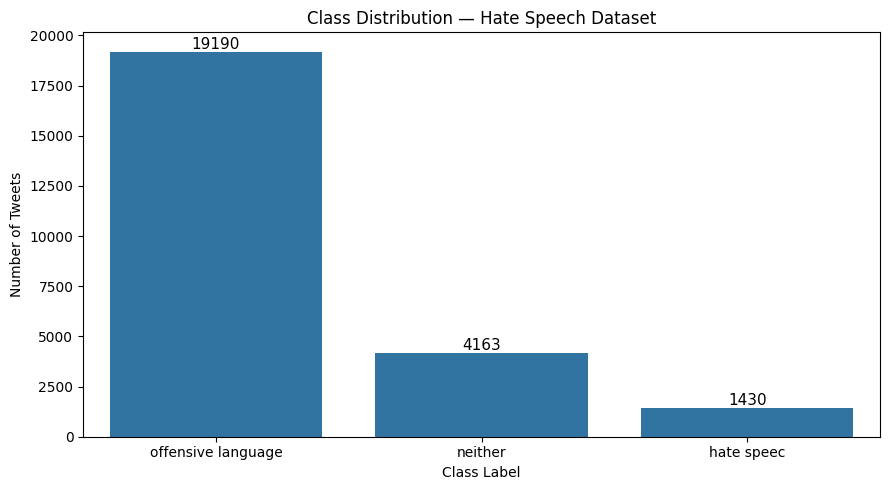

In [51]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    x='label',
    data=df,
    order=df['label'].value_counts().index
)

# Show the exact count above each bar so it's easy to read
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=11
    )

plt.title("Class Distribution — Hate Speech Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

# The chart makes the imbalance very obvious.
# Offensive language dominates at ~77%, which means models will naturally
# be biased toward predicting that class. We'll use stratified splitting
# later to at least keep the same ratio in train and test sets.

## Section 6 - Analyze Tweet Length

In [52]:
# Count how many words each tweet has
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print("Word Count Statistics:")
print(df['word_count'].describe())

Word Count Statistics:
count    24783.000000
mean        14.117016
std          6.825525
min          1.000000
25%          9.000000
50%         13.000000
75%         19.000000
max         52.000000
Name: word_count, dtype: float64


## Section 7 - Visualize Tweet Length Distribution

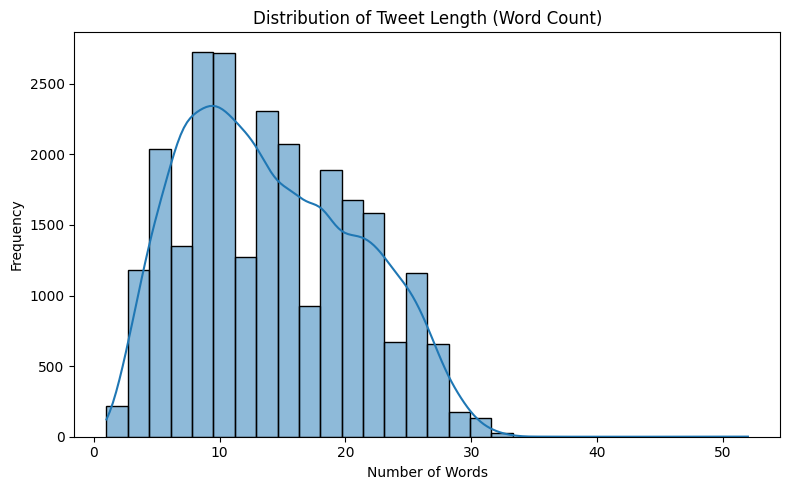

In [53]:
plt.figure(figsize=(8, 5))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Distribution of Tweet Length (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Most tweets are around 14 words — makes sense since Twitter has a character limit.
# The longest tweets go up to ~52 words but that's rare.
# This tells us we should use a relatively short max_length for padding.

## Section 8 - Text Cleaning Setup

Before we can feed text to a model, we need to clean it up. The cleaning pipeline does these steps in order:
1. Lowercase everything
2. Expand contractions ("don't" → "do not")
3. Strip URLs, @mentions, and #hashtags
4. Remove numbers and special characters
5. Remove stopwords ("the", "is", etc.) — they don't help with classification
6. Lemmatize — reduce words to their base form ("running" → "run")

In [54]:
# Load English stopwords and the lemmatizer — we'll use these inside the cleaning function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

## Section 9 - Text Cleaning Function

In [55]:
def clean_text(text):
    """
    Cleans a single tweet string and returns the processed version.
    Each step removes noise so the model can focus on actual meaning.
    """
    # Step 1: lowercase everything so "Hello" and "hello" are the same word
    text = text.lower()

    # Step 2: expand contractions — "can't" becomes "cannot", "don't" becomes "do not"
    text = contractions.fix(text)

    # Step 3: strip out hyperlinks (anything starting with http)
    text = re.sub(r"http\S+", "", text)

    # Step 4: remove @mentions — the username doesn't carry meaning
    text = re.sub(r"@\w+", "", text)

    # Step 5: remove #hashtags
    text = re.sub(r"#\w+", "", text)

    # Step 6: remove everything that's not a letter or space (numbers, punctuation, etc.)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Step 7: split into individual words, then remove stopwords and lemmatize
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join everything back into a single string
    return " ".join(words)

## Section 10 - Apply Cleaning to All Tweets

In [56]:
# Apply the cleaning function to every tweet — this might take a few seconds
df['clean_text'] = df['text'].apply(clean_text)

# Compare original vs cleaned side by side
df[['text', 'clean_text']].head(10)

,text,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman complain cleaning house amp man alway...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",shit blow meclaim faithful somebody still fuck...
6,"!!!!!!""@__BrighterDays: I can not just sit up ...",sit hate another bitch got much shit going
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,tired big bitch coming u skinny girl
8,""" &amp; you might not get ya bitch back &amp; ...",amp might get ya bitch back amp
9,""" @rhythmixx_ :hobbies include: fighting Maria...",hobby include fighting mariam bitch


## Section 11 - Word Cloud of Cleaned Text

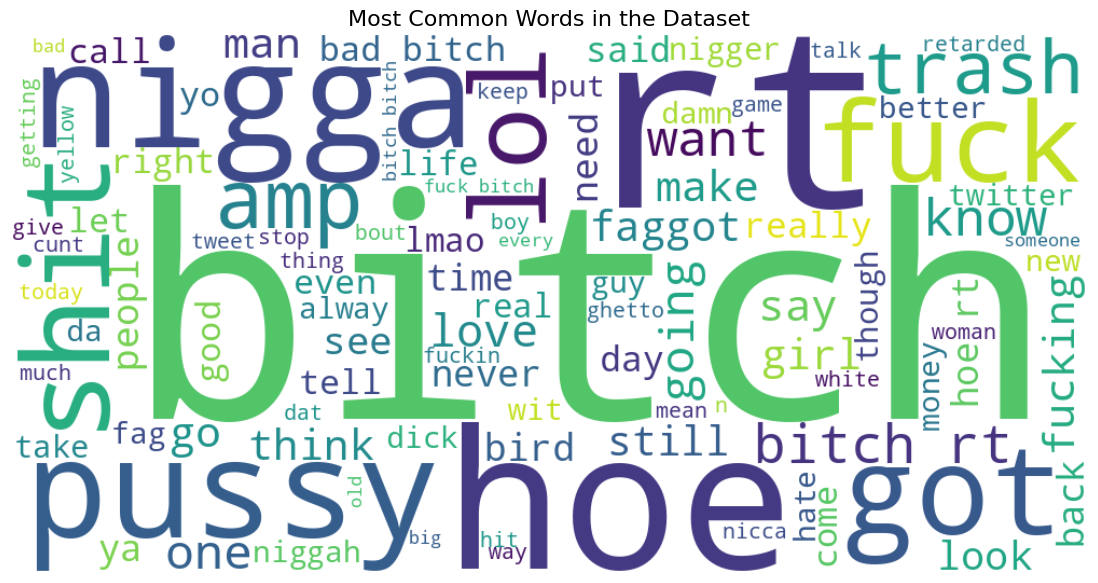

In [57]:
# Combine all cleaned tweets into one big string for the word cloud
all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(all_words)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in the Dataset", fontsize=16)
plt.show()

# The big words (bitch, nigga, fuck, hoe, etc.) appear in BOTH hate speech
# and offensive language, which is exactly why the task is hard —
# the vocabulary heavily overlaps between the two classes.

## Section 12 - Top 20 Most Frequent Words

In [58]:
# Count every word and grab the 20 most common ones
all_tokens = " ".join(df['clean_text']).split()
common_words = Counter(all_tokens).most_common(20)
common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
print(common_df)

     Word  Frequency
0   bitch      11305
1      rt       7634
2     hoe       4274
3    like       2819
4   pussy       2201
5   nigga       1988
6     got       1600
7      as       1567
8     get       1536
9    fuck       1447
10   shit       1279
11  trash       1147
12    lol       1063
13   want       1001
14   know        926
15    amp        844
16    one        750
17   love        749
18   girl        694
19     go        692


## Section 13 - Bar Chart: Top 20 Words

/tmp/ipykernel_6547/3831895812.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_df, palette='viridis')


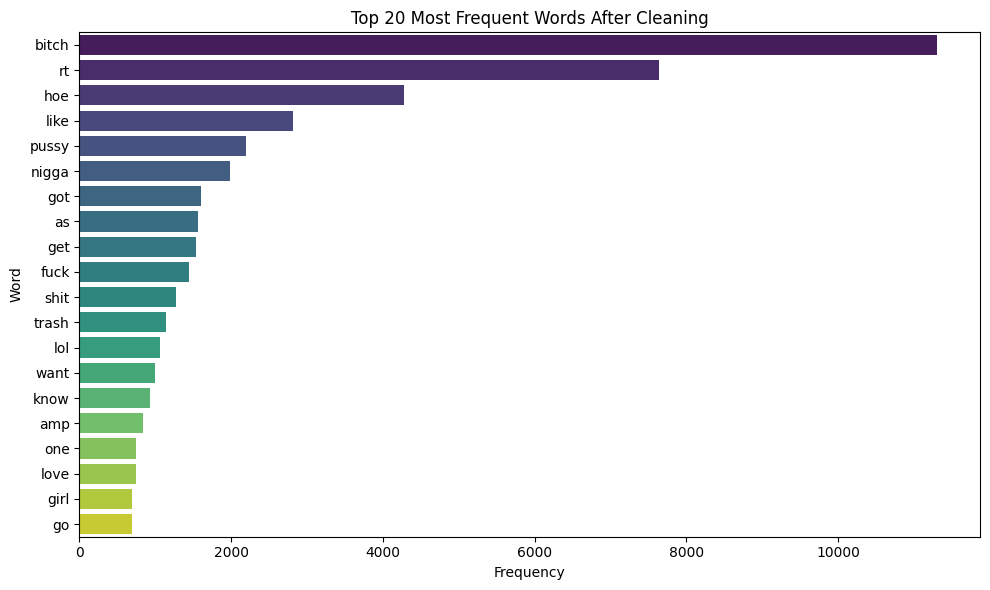

In [59]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=common_df, palette='viridis')
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.tight_layout()
plt.show()

## Section 14 - Train/Test Split

We split 80% for training and 20% for testing. The stratify=y argument ensures both splits have the same class ratio — this matters especially for the minority hate speech class.

In [60]:
X = df['clean_text']   # input features (the tweet text)
y = df['label']        # target labels

# 80/20 split with stratification to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps hate speech/offensive/neither ratio consistent
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 19826
Testing samples  : 4957


## Section 15 - Tokenization

Keras Tokenizer converts words to integers. We only keep the top 10,000 most frequent words — any rarer word gets ignored during encoding.

In [61]:
# We fit the tokenizer ONLY on training data (no data leakage)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

word_index  = tokenizer.word_index
vocab_size  = min(len(word_index) + 1, 10000)

print(f"Total unique words found : {len(word_index)}")
print(f"Vocabulary size used     : {vocab_size}")

Total unique words found : 16077
Vocabulary size used     : 10000


## Section 16 - Padding

Neural networks need all input sequences to be the same length. Instead of using the longest tweet (which would waste a lot of computation), we use the **95th percentile** of training sequence lengths as our max. Shorter sequences get zeros added at the end, longer ones get trimmed.

In [62]:
# Use 95th percentile to avoid inflating the sequence length because of a few very long tweets
sequence_lengths = [len(seq) for seq in X_train_seq]
max_length = int(np.percentile(sequence_lengths, 95))
print(f"Padding max length (95th percentile): {max_length} tokens")

# Pad/truncate all sequences to the same length
# 'post' means zeros are added at the END of shorter sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_length, padding='post', truncating='post')

print(f"Training data shape : {X_train_pad.shape}")
print(f"Testing data shape  : {X_test_pad.shape}")

Padding max length (95th percentile): 14 tokens
Training data shape : (19826, 14)
Testing data shape  : (4957, 14)


## Section 17 - Encode Labels

Our labels are strings like "hate_speech". We convert them to integers (0, 1, 2) so Keras can work with them using sparse_categorical_crossentropy.

In [63]:
# LabelEncoder maps each class name to an integer
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)  # fit on train, then transform
y_test_encoded  = encoder.transform(y_test)         # only transform test (no fitting!)

# Show what each integer maps to — important for reading predictions later
print("Label mapping:")
for i, cls in enumerate(encoder.classes_):
    print(f"  {i} -> {cls}")

# Build a reverse map for converting predictions back to class names
label_map = {i: cls for i, cls in enumerate(encoder.classes_)}

Label mapping:
  0 -> hate speec
  1 -> neither
  2 -> offensive language


## Section 18 - Model 1: Simple RNN

Our first model uses a basic recurrent layer. RNNs process sequences step by step, maintaining a hidden state that carries information from earlier tokens. They work well for short sequences like tweets but struggle with long-range dependencies.

In [64]:
# Build the Simple RNN model
model_rnn = Sequential(name="Simple_RNN")

# Embedding layer: maps each word integer to a dense 128-dim vector
# The model LEARNS these vectors during training (trainable=True by default)
model_rnn.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_length
))

# SimpleRNN: processes the sequence and outputs a single 64-dim vector
model_rnn.add(SimpleRNN(64))

# Dropout: randomly zeros out 50% of neurons during training to reduce overfitting
model_rnn.add(Dropout(0.5))

# Output layer: 3 neurons (one per class), softmax gives probability for each
model_rnn.add(Dense(3, activation='softmax'))

model_rnn.build(input_shape=(None, max_length))
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,547 (4.93 MB)

 Trainable params: 1,292,547 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

## Section 19 - Compile Model 1

In [65]:
# sparse_categorical_crossentropy works with integer labels (no one-hot encoding needed)
# Adam is a reliable adaptive optimizer that works well in most cases
model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Section 20 - Train Model 1

We use **EarlyStopping** to stop training once validation loss stops improving. This prevents overfitting and saves time.

In [66]:
# Create a fresh EarlyStopping callback for Model 1
# patience=3 means we wait 3 epochs without improvement before stopping
# restore_best_weights brings back the weights from the best epoch

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

early_stop_rnn = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,   # use 20% of training data for validation
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_rnn],
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(5.776806526806527), 1: np.float64(1.9845845845845846), 2: np.float64(0.4304759423310752)}
Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6625 - loss: 0.8266 - val_accuracy: 0.8230 - val_loss: 0.5328
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8307 - loss: 0.4421 - val_accuracy: 0.8142 - val_loss: 0.5126
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9042 - loss: 0.2337 - val_accuracy: 0.8313 - val_loss: 0.4697
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9385 - loss: 0.1554 - val_accuracy: 0.8144 - val_loss: 0.5684
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9533 - loss: 0.1187 - val_accuracy: 0.8462 - val_loss: 0.5071
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9622 - loss: 0.0968 - val_accuracy: 0.8154 - val_loss: 0.6509
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


## Section 21 - Plot Training Curves: Model 1 (RNN)

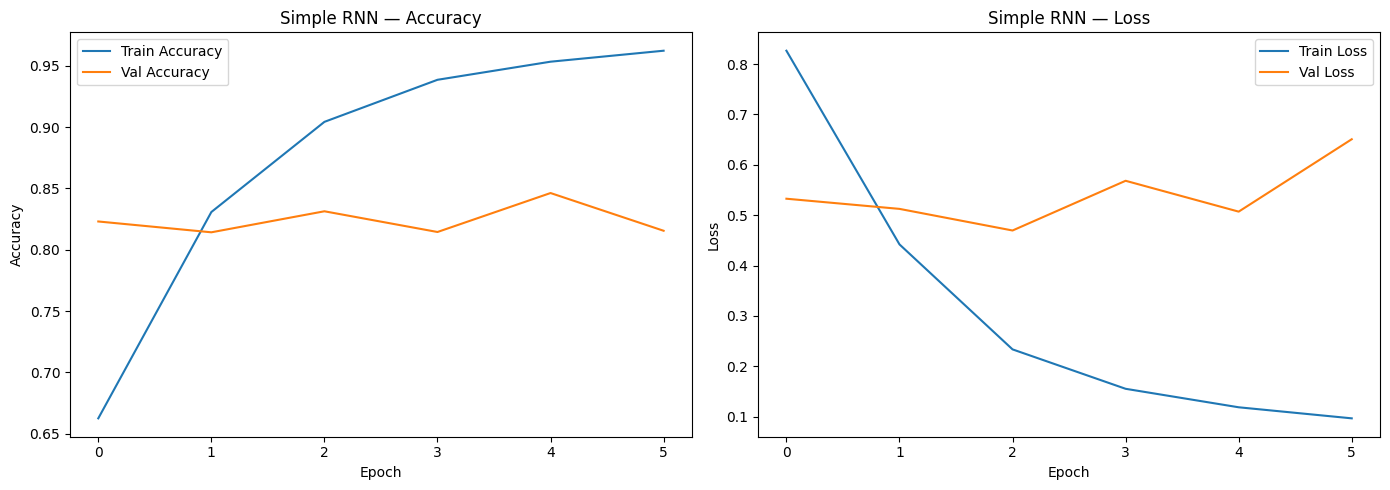

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_rnn.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title("Simple RNN — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss plot
axes[1].plot(history_rnn.history['loss'],     label='Train Loss')
axes[1].plot(history_rnn.history['val_loss'], label='Val Loss')
axes[1].set_title("Simple RNN — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 22 - Evaluate Model 1 (Simple RNN)

In [68]:
# Get raw probability output, then pick the class with highest probability
rnn_pred = model_rnn.predict(X_test_pad)
rnn_pred_classes = np.argmax(rnn_pred, axis=1)

print("===== Simple RNN Evaluation =====")
print(f"\nAccuracy: {accuracy_score(y_test_encoded, rnn_pred_classes):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_encoded, rnn_pred_classes,
    target_names=encoder.classes_
))

# Note: high overall accuracy can be misleading here because the model
# mostly sees offensive language (77% of data) and learns to predict that by default.

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
===== Simple RNN Evaluation =====

Accuracy: 0.8229

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.24      0.42      0.30       286
           neither       0.72      0.83      0.77       833
offensive language       0.93      0.85      0.89      3838

          accuracy                           0.82      4957
         macro avg       0.63      0.70      0.66      4957
      weighted avg       0.86      0.82      0.84      4957



## Section 23 - Confusion Matrix: Model 1 (RNN)

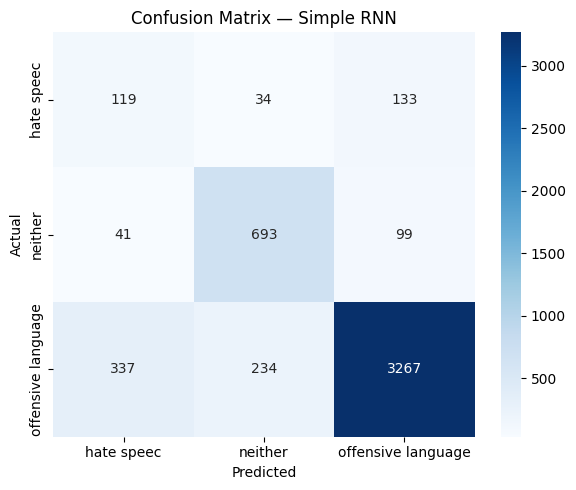

In [69]:
cm_rnn = confusion_matrix(y_test_encoded, rnn_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rnn, annot=True, fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap='Blues'
)
plt.title("Confusion Matrix — Simple RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# The off-diagonal cells are mistakes.
# A lot of hate speech tweets will likely be classified as offensive language
# because they share very similar vocabulary.

## Section 24 - Model 2: LSTM

LSTM (Long Short-Term Memory) is an improved RNN that uses gates to control what information to remember and forget. It handles longer sequences better than Simple RNN and avoids the vanishing gradient problem.

In [70]:
# Build the LSTM model — same structure as RNN but with LSTM instead of SimpleRNN
model_lstm = Sequential(name="LSTM_Trainable_Embedding")

# Trainable embedding layer — same setup as RNN model
model_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=128,
    input_length=max_length
))

# LSTM layer: 64 units. The gating mechanism helps it capture longer dependencies
model_lstm.add(LSTM(64))

# Dropout for regularization
model_lstm.add(Dropout(0.5))

# Output layer: 3 classes
model_lstm.add(Dense(3, activation='softmax'))

model_lstm.build(input_shape=(None, max_length))
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,603 (5.07 MB)

 Trainable params: 1,329,603 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

## Section 25 - Compile Model 2

In [71]:
model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Section 26 - Train Model 2

In [72]:
# Fresh EarlyStopping for Model 2 — always create a new instance per model
# Reusing the same callback object can cause issues with internal state

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_lstm],
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(5.776806526806527), 1: np.float64(1.9845845845845846), 2: np.float64(0.4304759423310752)}
Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6961 - loss: 0.7734 - val_accuracy: 0.8174 - val_loss: 0.5067
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8298 - loss: 0.4208 - val_accuracy: 0.8376 - val_loss: 0.4208
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8769 - loss: 0.2969 - val_accuracy: 0.8232 - val_loss: 0.4695
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8992 - loss: 0.2251 - val_accuracy: 0.7915 - val_loss: 0.5870
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9182 - loss: 0.1888 - val_accuracy: 0.8038 - val_loss: 0.5506
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


## Section 27 - Plot Training Curves: Model 2 (LSTM)

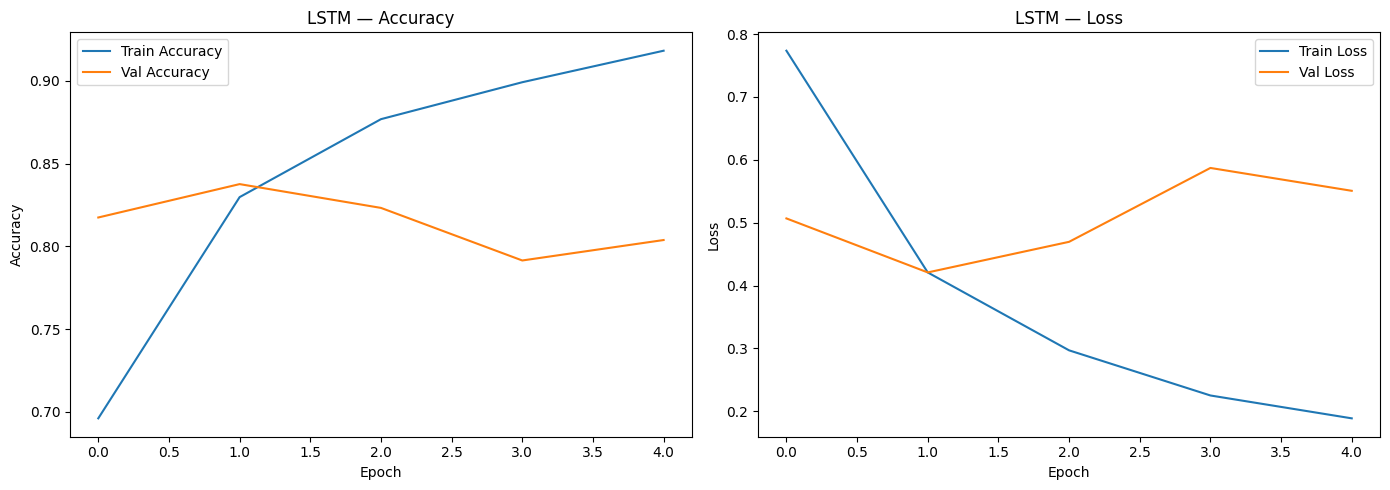

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title("LSTM — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_lstm.history['loss'],     label='Train Loss')
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss')
axes[1].set_title("LSTM — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 28 - Evaluate Model 2 (LSTM)

In [74]:
# Predict on test set
lstm_pred = model_lstm.predict(X_test_pad)
lstm_pred_classes = np.argmax(lstm_pred, axis=1)

print("===== LSTM Evaluation =====")
print(f"\nAccuracy: {accuracy_score(y_test_encoded, lstm_pred_classes):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_encoded, lstm_pred_classes,
    target_names=encoder.classes_
))

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
===== LSTM Evaluation =====

Accuracy: 0.8449

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.31      0.59      0.41       286
           neither       0.75      0.92      0.82       833
offensive language       0.96      0.85      0.90      3838

          accuracy                           0.84      4957
         macro avg       0.67      0.79      0.71      4957
      weighted avg       0.89      0.84      0.86      4957



## Section 29 - Confusion Matrix: Model 2 (LSTM)

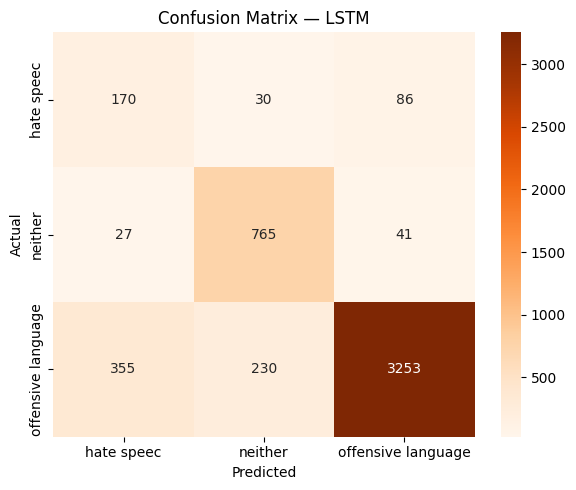

In [75]:
cm_lstm = confusion_matrix(y_test_encoded, lstm_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lstm, annot=True, fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap='Oranges'
)
plt.title("Confusion Matrix — LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Section 30 - Load Pretrained Word2Vec Embeddings

For Model 3, instead of learning word vectors from scratch, we use **Word2Vec** — vectors pretrained by Google on 100 billion words from Google News. This gives the model a head start with real-world semantic relationships.

**Note:** word2vec-google-news-300 uses 300-dimensional vectors, which provide richer semantic representations than smaller embeddings.

In [76]:
print("Loading Word2Vec embeddings (this may take a minute the first time)...")
w2v_model = api.load('word2vec-google-news-300')
print("Word2Vec loaded! Vocabulary size:", len(w2v_model.key_to_index))

Loading Word2Vec embeddings (this may take a minute the first time)...
Word2Vec loaded! Vocabulary size: 3000000


## Section 31 - Build the Word2Vec Embedding Matrix

We create a matrix where each row corresponds to a word in our vocabulary. If that word exists in Word2Vec, we use its pretrained vector. If not (e.g. slang like "smh" or "lol"), the row stays as zeros.

In [77]:
embedding_dim = 300  # must match Word2Vec dimensions

# Initialize with zeros — words not in Word2Vec will stay as zero vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim))

found_count = 0
for word, i in word_index.items():
    if i >= vocab_size:
        continue                          # skip words outside our vocab limit
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word]   # use the pretrained vector
        found_count += 1

coverage = found_count / min(len(word_index), vocab_size) * 100
print(f"Words found in Word2Vec: {found_count} / {min(len(word_index), vocab_size)} ({coverage:.1f}% coverage)")
print("Words NOT in Word2Vec get zero vectors — mostly slang and rare words.")

Words found in Word2Vec: 8083 / 10000 (80.8% coverage)
Words NOT in Word2Vec get zero vectors — mostly slang and rare words.


## Section 32 - Model 3: LSTM + Word2Vec Embeddings

Same LSTM architecture as Model 2, but the embedding layer is initialized with Word2Vec vectors and fine-tuned (trainable=True). This allows the embeddings to adapt to the tweet-specific vocabulary while benefiting from Word2Vec's pretrained knowledge.

In [78]:
model_w2v = Sequential(name="LSTM_Word2Vec_Embeddings")

# Embedding layer initialized with Word2Vec weights, fine-tuned during training
# trainable=True lets embeddings adapt to tweet-specific vocabulary
model_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],   # load the pretrained Word2Vec vectors
    input_length=max_length,
    trainable=True                # fine-tune embeddings to adapt to tweet slang
))

# LSTM layer
model_w2v.add(LSTM(64))

# Dropout
model_w2v.add(Dropout(0.5))

# Output: 3 classes
model_w2v.add(Dense(3, activation='softmax'))

model_w2v.build(input_shape=(None, max_length))
model_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Word2Vec_Embeddings"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 14, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,093,635 (11.80 MB)

 Trainable params: 3,093,635 (11.80 MB)

 Non-trainable params: 0 (0.00 B)

## Section 33 - Compile Model 3

In [79]:
model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Section 34 - Train Model 3

In [80]:
# Fresh early stopping callback for Model 3

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

early_stop_w2v = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_w2v = model_w2v.fit(
    X_train_pad,
    y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop_w2v],
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(5.776806526806527), 1: np.float64(1.9845845845845846), 2: np.float64(0.4304759423310752)}
Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.7344 - loss: 0.6939 - val_accuracy: 0.8447 - val_loss: 0.4324
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.8398 - loss: 0.4054 - val_accuracy: 0.8172 - val_loss: 0.5053
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.8747 - loss: 0.2855 - val_accuracy: 0.8210 - val_loss: 0.4986
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.8992 - loss: 0.2163 - val_accuracy: 0.8454 - val_loss: 0.4026
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.9239 - loss: 0.1662 - val_accuracy: 0.8177 - val_loss: 0.5878
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.9302 - loss: 0.1436 - val_accuracy: 0.8434 - val_loss: 0.5351
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9408 - loss: 0.1247 - val_accura

## Section 35 - Plot Training Curves: Model 3 (LSTM + Word2Vec)

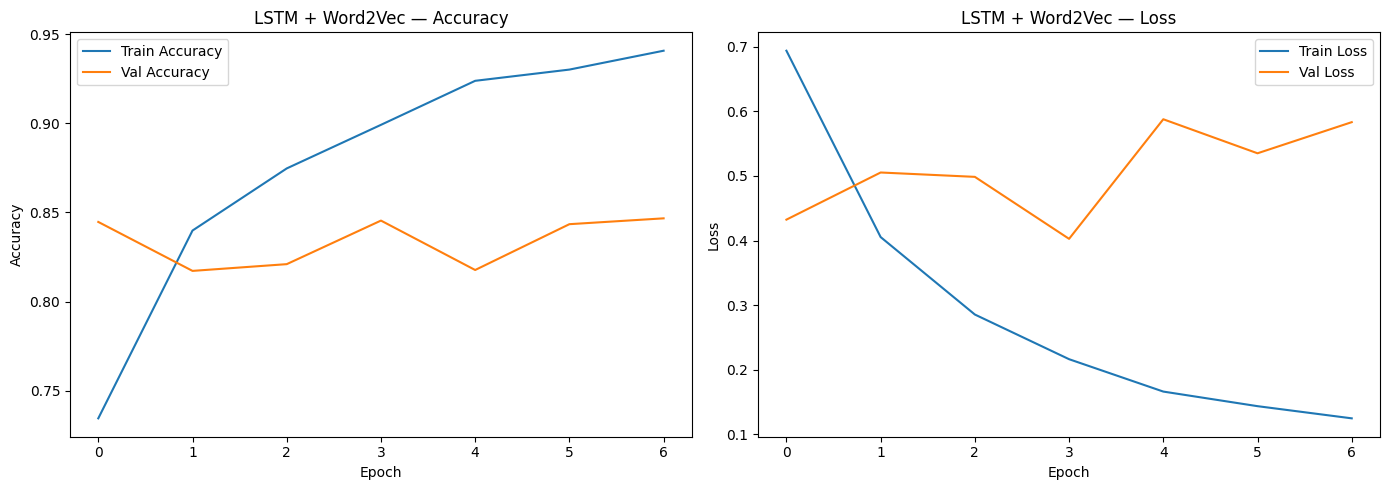

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_w2v.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_w2v.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title("LSTM + Word2Vec — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_w2v.history['loss'],     label='Train Loss')
axes[1].plot(history_w2v.history['val_loss'], label='Val Loss')
axes[1].set_title("LSTM + Word2Vec — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 36 - Evaluate Model 3 (LSTM + Word2Vec)

In [82]:
w2v_pred = model_w2v.predict(X_test_pad)
w2v_pred_classes = np.argmax(w2v_pred, axis=1)

print("===== LSTM + Word2Vec Evaluation =====")
print(f"\nAccuracy: {accuracy_score(y_test_encoded, w2v_pred_classes):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test_encoded, w2v_pred_classes,
    target_names=encoder.classes_
))

# Word2Vec was trained on Google News — some tweet slang may be OOV.
# Fine-tuning (trainable=True) helps the embeddings adapt to tweet vocabulary.

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
===== LSTM + Word2Vec Evaluation =====

Accuracy: 0.8489

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.29      0.52      0.37       286
           neither       0.79      0.87      0.83       833
offensive language       0.94      0.87      0.90      3838

          accuracy                           0.85      4957
         macro avg       0.68      0.75      0.70      4957
      weighted avg       0.88      0.85      0.86      4957



## Section 37 - Confusion Matrix: Model 3 (LSTM + Word2Vec)

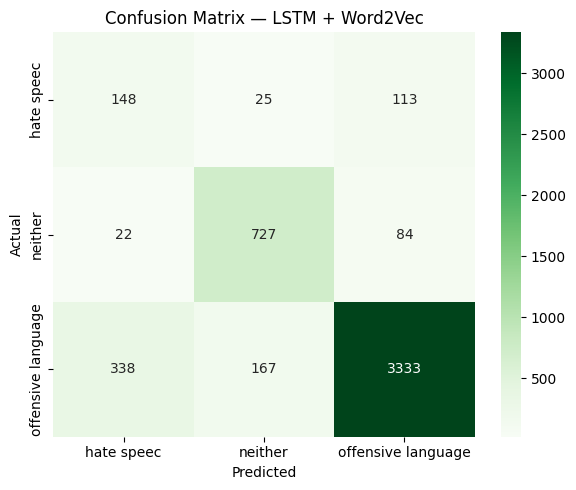

In [83]:
cm_w2v = confusion_matrix(y_test_encoded, w2v_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_w2v, annot=True, fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap='Greens'
)
plt.title("Confusion Matrix — LSTM + Word2Vec")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Section 38 - Compare All Three Models

In [84]:
# Build a summary DataFrame for easy comparison
results = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Accuracy': [
        accuracy_score(y_test_encoded, rnn_pred_classes),
        accuracy_score(y_test_encoded, lstm_pred_classes),
        accuracy_score(y_test_encoded, w2v_pred_classes)
    ]
})

results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
print(results.to_string(index=False))

          Model  Accuracy  Accuracy (%)
     Simple RNN  0.822877         82.29
           LSTM  0.844866         84.49
LSTM + Word2Vec  0.848901         84.89


## Section 39 - Accuracy Comparison Bar Chart

/tmp/ipykernel_6547/4112593157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Accuracy', data=results, palette='Set2')


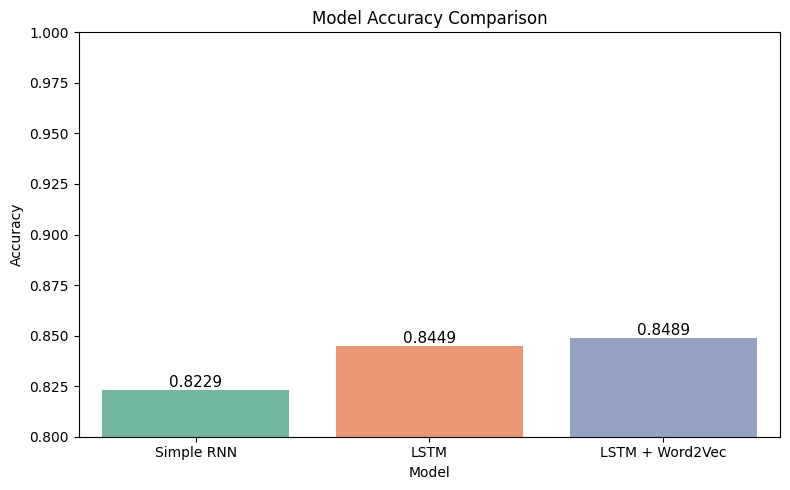

In [85]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Model', y='Accuracy', data=results, palette='Set2')

# Add accuracy values on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.4f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

plt.title("Model Accuracy Comparison")
plt.ylim(0.80, 1.0)   # zoom in so differences are visible
plt.tight_layout()
plt.show()

## Section 40 - Validation Accuracy Over Epochs (All Models)

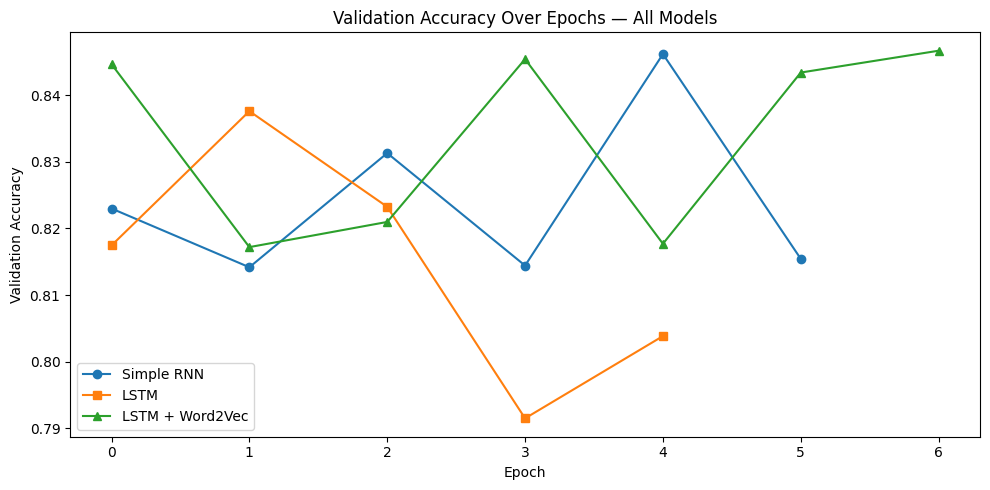

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],   label='Simple RNN',   marker='o')
plt.plot(history_lstm.history['val_accuracy'],  label='LSTM',          marker='s')
plt.plot(history_w2v.history['val_accuracy'], label='LSTM + Word2Vec',  marker='^')
plt.title("Validation Accuracy Over Epochs — All Models")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Note: different models may have trained for different numbers of epochs
# because EarlyStopping stopped them at different points.

---
## Section 41 - Error Analysis

### 4.5.4 - What did the models get wrong, and why?

We'll look at specific misclassified examples from the LSTM model (Model 2), which tends to have the most interesting errors around the hate_speech class.

In [87]:
# Find all the examples where LSTM got the wrong answer
misclassified_idx = np.where(lstm_pred_classes != y_test_encoded)[0]

print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test_encoded)} test samples")
print(f"Error rate: {len(misclassified_idx) / len(y_test_encoded) * 100:.2f}%\n")

print("===== 3 Sample Misclassified Tweets =====\n")

# Show 3 specific wrong predictions with full context
for idx in misclassified_idx[:3]:
    original  = X_test.iloc[idx]                   # original (uncleaned) tweet
    true_cls  = label_map[y_test_encoded[idx]]      # what it actually is
    pred_cls  = label_map[lstm_pred_classes[idx]]   # what LSTM predicted
    print(f"Tweet   : {original}")
    print(f"True    : {true_cls}")
    print(f"Predicted: {pred_cls}")
    print("-" * 60)

Total misclassified: 769 out of 4957 test samples
Error rate: 15.51%

===== 3 Sample Misclassified Tweets =====

Tweet   : hardly get sexso opportunity sick present giving pussyand boy generous
True    : offensive language
Predicted: hate speec
------------------------------------------------------------
Tweet   : full nigger
True    : offensive language
Predicted: hate speec
------------------------------------------------------------
Tweet   : nigga send hate thru bitch
True    : offensive language
Predicted: hate speec
------------------------------------------------------------


### Why Does the Model Make These Mistakes?

**1. Class Imbalance is the Biggest Culprit**  
Hate speech is only ~5.8% of the dataset. The model rarely sees it during training, so it doesn't learn the subtle difference between hate speech and offensive language. When unsure, it defaults to predicting "offensive_language" — which is statistically safer.

**2. Vocabulary Overlap Between Classes**  
Both hate speech and offensive language use very similar words (racial slurs, profanity). The difference between the two is usually *intent and context* — "I hate [group]" targets an identity, while general profanity may not. A simple word-level model can't capture this kind of intent.

**3. The Boundary is Genuinely Blurry**  
Even human annotators would sometimes disagree on whether a tweet is hate speech or just offensive. Some tweets contain slurs in an offensive but non-targeted way. This means some "errors" the model makes might actually be reasonable calls.

**4. Short Sequence Length Loses Context**  
With max_length=14, some important words at the end of longer tweets get cut off. The model might miss the part of a tweet that would have clarified its true label.

### Suggestions for Improvement

- **Use class weights** during training so wrong predictions on hate speech are penalized more heavily
- **Oversample hate speech** using SMOTE or manual duplication to balance the training set
- **Use domain-adapted Word2Vec** trained on Twitter data for better slang coverage
- **Set trainable=True** for Word2Vec embeddings so they can adapt to the tweet vocabulary (already enabled in Model 3)
- **Try a Bidirectional LSTM** which reads the sequence from both directions and captures more context
- **Fine-tune a Transformer model** like BERT — it understands context far better than RNN-based models

## Section 42 - Real-Time Prediction Function

A simple Python function to classify any tweet using our best-performing model.

In [88]:
def predict_tweet(text, model=None, model_name="LSTM"):
    """
    Takes a raw tweet string and returns the predicted class.
    You can pass any of the three models — defaults to LSTM.
    """
    if model is None:
        model = model_lstm   # default to LSTM (generally best on hate speech)

    # Step 1: run through the same cleaning pipeline as training data
    cleaned = clean_text(text)

    # Step 2: convert to sequence of integers
    seq = tokenizer.texts_to_sequences([cleaned])

    # Step 3: pad to the same length the model expects
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    # Step 4: get model prediction and convert to class name
    probs = model.predict(padded, verbose=0)
    predicted_idx = np.argmax(probs)
    predicted_class = label_map[predicted_idx]
    confidence = probs[0][predicted_idx] * 100

    print(f"[{model_name}] Input   : '{text}'")
    print(f"[{model_name}] Cleaned : '{cleaned}'")
    print(f"[{model_name}] Result  : {predicted_class} ({confidence:.1f}% confidence)")
    return predicted_class

# Quick test on a few examples
predict_tweet("You're so stupid I hate you!")
print()
predict_tweet("What a beautiful day today")
print()
predict_tweet("I hate all people from that country", model=model_lstm, model_name="LSTM")

[LSTM] Input   : 'You're so stupid I hate you!'
[LSTM] Cleaned : 'stupid hate'
[LSTM] Result  : hate speec (47.2% confidence)

[LSTM] Input   : 'What a beautiful day today'
[LSTM] Cleaned : 'beautiful day today'
[LSTM] Result  : neither (92.6% confidence)

[LSTM] Input   : 'I hate all people from that country'
[LSTM] Cleaned : 'hate people country'
[LSTM] Result  : hate speec (60.3% confidence)


'hate speec'

## Section 43 - GUI for Real-Time Prediction

Using Gradio to build a simple web interface where you can type a tweet and get a prediction.

In [89]:
import gradio as gr

def gradio_predict(tweet_text, model_choice):
    """
    Gradio-compatible prediction function.
    Takes the tweet and the selected model name, returns the prediction.
    """
    # Map the dropdown selection to the actual model object
    model_map = {
        "Simple RNN": model_rnn,
        "LSTM": model_lstm,
        "LSTM + Word2Vec": model_w2v
    }

    selected_model = model_map[model_choice]

    # Run the cleaning and prediction pipeline
    cleaned = clean_text(tweet_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    probs           = selected_model.predict(padded, verbose=0)
    predicted_idx   = np.argmax(probs)
    predicted_label = label_map[predicted_idx]
    confidence      = probs[0][predicted_idx] * 100

    result = f"Prediction: {predicted_label} . Confidence: {confidence:.1f}%"
    return result

# Build the Gradio interface
demo = gr.Interface(
    fn=gradio_predict,
    inputs=[
        gr.Textbox(lines=3, placeholder="Type a tweet here...", label="Tweet"),
        gr.Radio(
            choices=["Simple RNN", "LSTM", "LSTM + Word2Vec"],
            value="LSTM",
            label="Choose Model"
        )
    ],
    outputs=gr.Textbox(label="Result"),
    title="Hate Speech Detector",
    description="Type any tweet to classify it as Hate Speech, Offensive Language, or Neither.",

)

# Launch the interface — share=True creates a public link (works in Colab)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3935eb00fe474c636a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
